# Assignment 4

**Group Members:** Nikhilesh Belulkar, Ashish Puri, Roshan Patel

## Part A

Annual: $\mu = 8\%$, $\sigma = 4\%$; returns normal i.i.d. One period:

$$\mu_{\text{period}} = \frac{\mu_{\text{annual}}}{n}, \qquad \sigma_{\text{period}} = \frac{\sigma_{\text{annual}}}{\sqrt{n}}$$

where $n$ is the number of such periods per year. Daily uses $n = 252$ trading days.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad
mu_a, sigma_a = 0.08, 0.04

N_DAYS = 252


def daily_winning_updown_sharpe(mu_annual: float, sigma_annual: float):
    """Daily i.i.d. normal; winning rate, up-down ratio, annual Sharpe (μ/σ, rf=0)."""
    mu_p = mu_annual / N_DAYS
    sigma_p = sigma_annual / np.sqrt(N_DAYS)

    def f_R(r):
        return stats.norm.pdf(r, loc=mu_p, scale=sigma_p)

    num_pos, _ = quad(lambda r: r * f_R(r), 0.0, np.inf)
    den_pos, _ = quad(f_R, 0.0, np.inf)
    num_neg, _ = quad(lambda r: r * f_R(r), -np.inf, 0.0)
    den_neg, _ = quad(f_R, -np.inf, 0.0)
    E_pos = num_pos / den_pos
    E_neg = num_neg / den_neg
    winning_rate = den_pos
    up_down = E_pos / abs(E_neg)
    sharpe = mu_annual / sigma_annual if sigma_annual > 0 else np.nan
    return winning_rate, up_down, sharpe

### A i)

In [51]:
n = 1  # one year
mu_p = mu_a / n
sigma_p = sigma_a / np.sqrt(n)
p_loss = stats.norm.cdf(0.0, loc=mu_p, scale=sigma_p)

print("A(i)  P(loss in a given year)")
print(f"      μ_year = {mu_p:.4f}, σ_year = {sigma_p:.4f}")
print(f"      Answer: {p_loss:.6f}  ({100*p_loss:.4f}%)")

A(i)  P(loss in a given year)
      μ_year = 0.0800, σ_year = 0.0400
      Answer: 0.022750  (2.2750%)


### A ii)

In [52]:
n = 4  # quarters per year
mu_p = mu_a / n
sigma_p = sigma_a / np.sqrt(n)
p_loss = stats.norm.cdf(0.0, loc=mu_p, scale=sigma_p)

print("A(ii) P(loss in a given quarter)")
print(f"      μ_quarter = {mu_p:.4f}, σ_quarter = {sigma_p:.4f}")
print(f"      Answer: {p_loss:.6f}  ({100*p_loss:.4f}%)")

A(ii) P(loss in a given quarter)
      μ_quarter = 0.0200, σ_quarter = 0.0200
      Answer: 0.158655  (15.8655%)


### A iii)

In [53]:
n = 12  # months per year
mu_p = mu_a / n
sigma_p = sigma_a / np.sqrt(n)
p_loss = stats.norm.cdf(0.0, loc=mu_p, scale=sigma_p)

print("A(iii) P(loss in a given month)")
print(f"      μ_month = {mu_p:.6f}, σ_month = {sigma_p:.6f}")
print(f"      Answer: {p_loss:.6f}  ({100*p_loss:.4f}%)")

A(iii) P(loss in a given month)
      μ_month = 0.006667, σ_month = 0.011547
      Answer: 0.281851  (28.1851%)


### A iv)

In [54]:
n = 252  # trading days per year
mu_p = mu_a / n
sigma_p = sigma_a / np.sqrt(n)
p_loss = stats.norm.cdf(0.0, loc=mu_p, scale=sigma_p)

print("A(iv) P(loss on a given day)")
print(f"      μ_day = {mu_p:.8f}, σ_day = {sigma_p:.6f}")
print(f"      Answer: {p_loss:.6f}  ({100*p_loss:.4f}%)")

A(iv) P(loss on a given day)
      μ_day = 0.00031746, σ_day = 0.002520
      Answer: 0.449871  (44.9871%)


### A v)

In [55]:
notional = 500_000_000.0
n = 4
mu_q = mu_a / n
sigma_q = sigma_a / np.sqrt(n)

e_pnl = notional * mu_q
std_pnl = notional * sigma_q

print("A(v)  $500M invested, end of first quarter")
print(f"      Expected dollar PnL:     ${e_pnl:,.0f}")
print(f"      Std dev of dollar PnL: ${std_pnl:,.0f}")
print(f"      ±2σ band for dollar PnL: [${e_pnl - 2*std_pnl:,.0f}, ${e_pnl + 2*std_pnl:,.0f}]")

A(v)  $500M invested, end of first quarter
      Expected dollar PnL:     $10,000,000
      Std dev of dollar PnL: $10,000,000
      ±2σ band for dollar PnL: [$-10,000,000, $30,000,000]


## Part B — Winning rate, conditional means, up–down ratio, loss ratio

Uses $\mu_p$, $\sigma_p$ from **A(iv)** (daily $R \sim \mathcal{N}(\mu_p, \sigma_p^2)$). Run **A(iv)** before this cell.

**Winning rate** (fraction of up days):

$$P(R > 0) = \int_0^{\infty} f_R(r)\,dr$$

where $f_R$ is the normal PDF with $(\mu_p, \sigma_p)$ — computed as `1 - cdf(0)`.

**Conditional expectations** (definition, no standardization): the expected return **given** an up or down day is the integral of $r \cdot f_R(r)$ over that region, divided by the probability of that region:

$$\mathbb{E}[R \mid R > 0] = \frac{\displaystyle\int_0^{\infty} r\, f_R(r)\,dr}{\displaystyle\int_0^{\infty} f_R(r)\,dr}, \qquad
\mathbb{E}[R \mid R < 0] = \frac{\displaystyle\int_{-\infty}^{0} r\, f_R(r)\,dr}{\displaystyle\int_{-\infty}^{0} f_R(r)\,dr}$$

We evaluate the integrals numerically with `scipy.integrate.quad` and the same $\mathcal{N}(\mu_p, \sigma_p^2)$ density throughout.

- **Up–down ratio** (assignment): $\dfrac{\mathbb{E}[R \mid R > 0]}{\big|\mathbb{E}[R \mid R < 0]\big|}$.
- **Loss ratio** (conditional): $\dfrac{\big|\mathbb{E}[R \mid R < 0]\big|}{\mathbb{E}[R \mid R > 0]}$ (reciprocal of up–down).

In [56]:
# Uses mu_p, sigma_p from A(iv); EV via definition: ∫ r f(r) dr / P(region)
def f_R(r):
    return stats.norm.pdf(r, loc=mu_p, scale=sigma_p)

num_pos, _ = quad(lambda r: r * f_R(r), 0.0, np.inf)
den_pos, _ = quad(f_R, 0.0, np.inf)
E_R_given_pos = num_pos / den_pos

num_neg, _ = quad(lambda r: r * f_R(r), -np.inf, 0.0)
den_neg, _ = quad(f_R, -np.inf, 0.0)
E_R_given_neg = num_neg / den_neg

winning_rate = den_pos  # P(R > 0)
loss_rate = den_neg   # P(R < 0)

up_down_ratio = E_R_given_pos / abs(E_R_given_neg)
loss_ratio_conditional = abs(E_R_given_neg) / E_R_given_pos

print("A(iv) daily: μ_p = {:.8f}, σ_p = {:.6f}".format(mu_p, sigma_p))
print()
print("Winning rate P(R > 0)     = {:.6f}  ({:.2f}%)".format(winning_rate, 100 * winning_rate))
print("Loss rate   P(R < 0)     = {:.6f}  ({:.2f}%)".format(loss_rate, 100 * loss_rate))
print()
print("E[R | R > 0]             = {:.8f}".format(E_R_given_pos))
print("E[R | R < 0]             = {:.8f}".format(E_R_given_neg))
print()
print("Up-down ratio (E[up]/|E[down]|) = {:.6f}".format(up_down_ratio))
print("Loss ratio |E[down]|/E[up]      = {:.6f}".format(loss_ratio_conditional))

A(iv) daily: μ_p = 0.00031746, σ_p = 0.002520

Winning rate P(R > 0)     = 0.550129  (55.01%)
Loss rate   P(R < 0)     = 0.449871  (44.99%)

E[R | R > 0]             = 0.00213029
E[R | R < 0]             = -0.00189938

Up-down ratio (E[up]/|E[down]|) = 1.121571
Loss ratio |E[down]|/E[up]      = 0.891606


### B (i) — Vary $\sigma_{\text{annual}}$, hold $\mu = 8\%$

$\sigma$ steps by **0.25%** from **2%** to **12%** (annualized). Daily dynamics use the same scaling as Part A ($n=252$). **Sharpe** (annual, $r_f=0$): $\mu_{\text{annual}}/\sigma_{\text{annual}}$.

Table: three columns — **Winning rate**, **Up–down ratio**, **Sharpe**; one row per $\sigma$.

σ annual (%),Winning rate,Up-down ratio,Sharpe
2.00,0.5995,1.2577,4.0000
2.25,0.5886,1.2261,3.5556
2.50,0.5799,1.2014,3.2000
2.75,0.5727,1.1816,2.9091
3.00,0.5667,1.1653,2.6667
3.25,0.5616,1.1516,2.4615
3.50,0.5572,1.1401,2.2857
3.75,0.5535,1.1302,2.1333
4.00,0.5501,1.1216,2.0000
4.25,0.5472,1.1140,1.8824


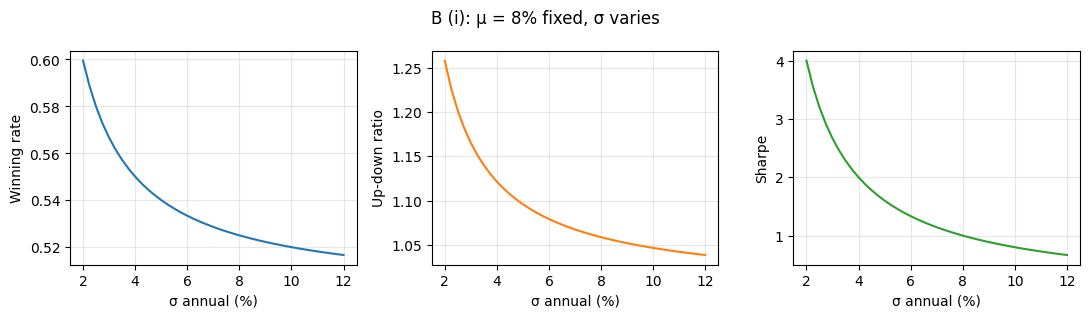

In [57]:
sigma_grid_pct = np.arange(2.0, 12.25, 0.25)
mu_fixed = 0.08
rows_bi = []
for spct in sigma_grid_pct:
    s = spct / 100.0
    wr, ud, sh = daily_winning_updown_sharpe(mu_fixed, s)
    rows_bi.append(
        {"σ annual (%)": spct, "Winning rate": wr, "Up-down ratio": ud, "Sharpe": sh}
    )
df_bi = pd.DataFrame(rows_bi)
display(
    df_bi.style.format(
        {"σ annual (%)": "{:.2f}", "Winning rate": "{:.4f}", "Up-down ratio": "{:.4f}", "Sharpe": "{:.4f}"}
    ).hide(axis="index")
)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharex=True)
x = df_bi["σ annual (%)"]
axes[0].plot(x, df_bi["Winning rate"], color="C0")
axes[0].set_ylabel("Winning rate")
axes[1].plot(x, df_bi["Up-down ratio"], color="C1")
axes[1].set_ylabel("Up-down ratio")
axes[2].plot(x, df_bi["Sharpe"], color="C2")
axes[2].set_ylabel("Sharpe")
for ax in axes:
    ax.set_xlabel("σ annual (%)")
    ax.grid(True, alpha=0.3)
fig.suptitle("B (i): μ = 8% fixed, σ varies")
fig.tight_layout()
plt.show()

### B (ii) — Vary $\mu_{\text{annual}}$, hold $\sigma = 4\%$

$\mu$ steps by **0.25%** from **2%** to **12%**. Same daily metrics and Sharpe definition as above.

μ annual (%),Winning rate,Up-down ratio,Sharpe
2.00,0.5126,1.0291,0.5000
2.25,0.5141,1.0328,0.5625
2.50,0.5157,1.0365,0.6250
2.75,0.5173,1.0402,0.6875
3.00,0.5188,1.0440,0.7500
3.25,0.5204,1.0477,0.8125
3.50,0.5220,1.0515,0.8750
3.75,0.5235,1.0553,0.9375
4.00,0.5251,1.0591,1.0000
4.25,0.5267,1.0629,1.0625


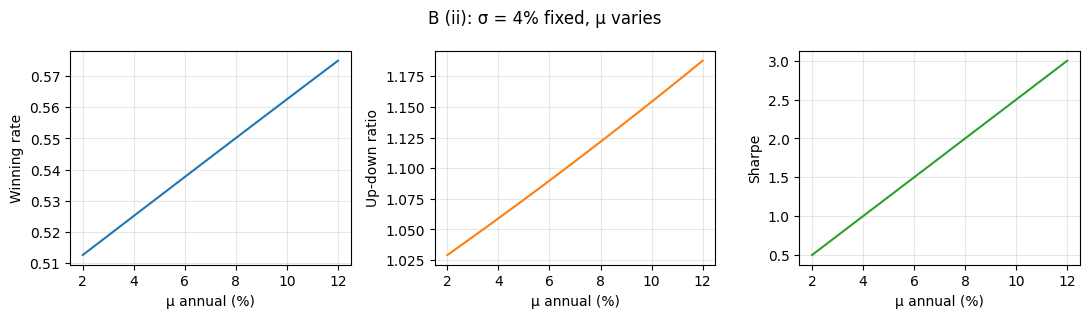

In [58]:
mu_grid_pct = np.arange(2.0, 12.25, 0.25)
sigma_fixed = 0.04
rows_bii = []
for mpct in mu_grid_pct:
    m = mpct / 100.0
    wr, ud, sh = daily_winning_updown_sharpe(m, sigma_fixed)
    rows_bii.append(
        {"μ annual (%)": mpct, "Winning rate": wr, "Up-down ratio": ud, "Sharpe": sh}
    )
df_bii = pd.DataFrame(rows_bii)
display(
    df_bii.style.format(
        {"μ annual (%)": "{:.2f}", "Winning rate": "{:.4f}", "Up-down ratio": "{:.4f}", "Sharpe": "{:.4f}"}
    ).hide(axis="index")
)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharex=True)
x = df_bii["μ annual (%)"]
axes[0].plot(x, df_bii["Winning rate"], color="C0")
axes[0].set_ylabel("Winning rate")
axes[1].plot(x, df_bii["Up-down ratio"], color="C1")
axes[1].set_ylabel("Up-down ratio")
axes[2].plot(x, df_bii["Sharpe"], color="C2")
axes[2].set_ylabel("Sharpe")
for ax in axes:
    ax.set_xlabel("μ annual (%)")
    ax.grid(True, alpha=0.3)
fig.suptitle("B (ii): σ = 4% fixed, μ varies")
fig.tight_layout()
plt.show()

### B (iii) - Relationship between winning rate, up-down ratio, and Sharpe Ratio

Under the assumptions of this problem (normal i.i.d. returns), the Sharpe Ratio is the **single sufficient statistic** that determines both the winning rate and the up-down ratio. Once you fix the distribution family (normal) and the independence structure (i.i.d.), specifying $\mu / \sigma$ fully pins down the shape of the daily return distribution up to scale, and therefore pins down both $P(R > 0)$ and $E[R \mid R > 0] / |E[R \mid R < 0]|$. The winning rate and up-down ratio are not independent measures of performance - they are both deterministic functions of the Sharpe Ratio.

**Evidence from B(i) - varying $\sigma$, fixed $\mu = 8\%$:**  
As $\sigma$ increases from 2% to 12%, the Sharpe Ratio falls from 4.0 to 0.67. The winning rate falls in lockstep (from 0.5995 to 0.5167) and the up-down ratio also falls (from 1.258 to 1.039). All three metrics degrade together - you cannot have a situation where the winning rate improves while the up-down ratio deteriorates, or vice versa, under normality.

**Evidence from B(ii) - varying $\mu$, fixed $\sigma = 4\%$:**  
As $\mu$ increases from 2% to 12%, the Sharpe Ratio rises from 0.5 to 3.0. The winning rate rises (from 0.5126 to 0.5749) and the up-down ratio rises (from 1.029 to 1.188). Again, all three move together.

**Two key assumptions are responsible for this tight linkage:**

1. **Normality.** The normal distribution is symmetric around its mean. Shifting the mean (changing $\mu / \sigma$) simultaneously increases the fraction of the distribution above zero (winning rate) and tilts the conditional expectations in favor of up days (up-down ratio). With a **skewed or fat-tailed** distribution, these metrics could diverge. For example, a strategy that sells deep out-of-the-money options could have a very high winning rate (many small premiums collected) but a very low up-down ratio (rare but catastrophic losses). Conversely, a momentum strategy might have a low winning rate but a high up-down ratio (few big wins, many small losses). Under normality, such profiles are impossible.

2. **i.i.d. (independent and identically distributed).** Independence means there is no autocorrelation, regime switching, or volatility clustering. Each day's return is drawn from the same distribution regardless of what happened yesterday. If returns were **positively autocorrelated** (momentum), winning and losing streaks would be longer than the i.i.d. model predicts, potentially inflating the observed up-down ratio relative to the winning rate. If returns were **negatively autocorrelated** (mean-reversion), streaks would be shorter. In either case, the tight one-to-one mapping between Sharpe, winning rate, and up-down ratio would break down, and the three metrics would carry partially independent information about the return process.

## Part C - Drawdown Probabilities via Monte Carlo

Back to the original setup: $\mu = 8\%$, $\sigma = 4\%$, Sharpe $= 2.0$, returns normal i.i.d.

**Drawdown definition:** the time (in trading days) between a fund's peak cumulative PnL and when cumulative PnL surpasses that previous peak.

**Constant-dollar assumption:** winnings are swept out, losses are replenished, so the notional invested remains constant. This means cumulative PnL is simply the running sum of daily returns (the notional cancels out of the drawdown duration calculation).

**Approach:** Monte Carlo simulation (no closed-form solution exists). We simulate many independent return paths, track the maximum drawdown duration in each path, and estimate probabilities from the empirical distribution.

In [59]:
def simulate_max_drawdown_duration(mu_annual, sigma_annual, n_years,
                                    n_sims=100_000, seed=42):
    """
    Monte Carlo estimate of the maximum consecutive drawdown duration.

    Uses a memory-efficient day-loop: O(n_sims) memory regardless of horizon.
    Returns the full array of max drawdown durations (one per simulation path)
    so the caller can compute P(dd >= k) for any threshold k from a single run.
    """
    mu_d = mu_annual / N_DAYS
    sigma_d = sigma_annual / np.sqrt(N_DAYS)
    n_days = int(n_years * N_DAYS)

    rng = np.random.default_rng(seed)

    cum_pnl    = np.zeros(n_sims)
    peak_pnl   = np.zeros(n_sims)
    cur_streak  = np.zeros(n_sims, dtype=np.int32)
    max_streak  = np.zeros(n_sims, dtype=np.int32)

    for _ in range(n_days):
        daily_r    = rng.normal(mu_d, sigma_d, n_sims)
        cum_pnl   += daily_r
        peak_pnl   = np.maximum(peak_pnl, cum_pnl)
        in_dd      = cum_pnl < peak_pnl
        cur_streak = np.where(in_dd, cur_streak + 1, 0)
        max_streak = np.maximum(max_streak, cur_streak)

    return max_streak

### C (i) - P(90-day drawdown) over a 5-year commitment

With $\mu = 8\%$, $\sigma = 4\%$ (SR $= 2$), what is the probability of observing a drawdown lasting at least 90 trading days over a 5-year period (1,260 trading days)?

We run 100,000 simulations and show a convergence plot to confirm the estimate has stabilized.

C(i)  P(90-day drawdown over 5 years)
      Simulations: 100,000
      Answer: 0.8941  (89.41%)
      Std error: 0.0010
      95% CI: [0.8922, 0.8960]


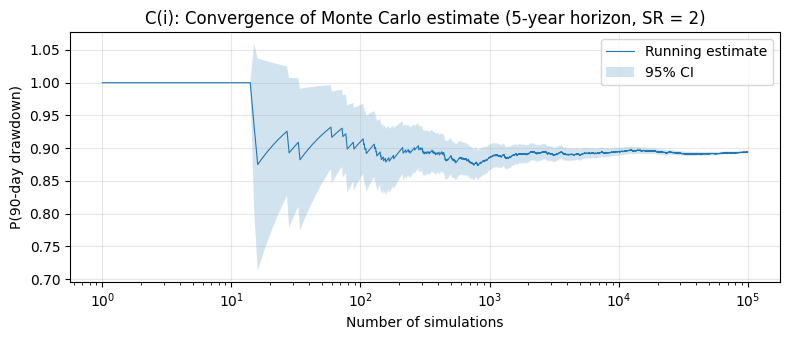

In [60]:
max_streak_5y = simulate_max_drawdown_duration(0.08, 0.04, n_years=5, n_sims=100_000, seed=42)

p_90 = np.mean(max_streak_5y >= 90)
se_90 = np.sqrt(p_90 * (1 - p_90) / len(max_streak_5y))

print("C(i)  P(90-day drawdown over 5 years)")
print(f"      Simulations: {len(max_streak_5y):,}")
print(f"      Answer: {p_90:.4f}  ({100*p_90:.2f}%)")
print(f"      Std error: {se_90:.4f}")
print(f"      95% CI: [{p_90 - 1.96*se_90:.4f}, {p_90 + 1.96*se_90:.4f}]")

# Convergence plot
has_90 = (max_streak_5y >= 90).astype(float)
ns = np.arange(1, len(has_90) + 1)
running_mean = np.cumsum(has_90) / ns
running_se = np.sqrt(running_mean * (1 - running_mean) / ns)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ns, running_mean, linewidth=0.8, label="Running estimate")
ax.fill_between(ns,
                running_mean - 1.96 * running_se,
                running_mean + 1.96 * running_se,
                alpha=0.2, label="95% CI")
ax.set_xlabel("Number of simulations")
ax.set_ylabel("P(90-day drawdown)")
ax.set_title("C(i): Convergence of Monte Carlo estimate (5-year horizon, SR = 2)")
ax.set_xscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### C (ii) - P(90-day and 120-day drawdown) over a 10-year commitment

Same assumptions as C(i), but with a 10-year horizon (2,520 trading days). We also examine how the probability of a 90-day drawdown changes as we vary the observation horizon from 1 to 10 years.

C(ii) 10-year horizon (SR = 2)
      P(90-day drawdown): 0.9907  (99.06%)
      95% CI: [0.9901, 0.9912]

      P(120-day drawdown): 0.9185  (91.85%)
      95% CI: [0.9168, 0.9202]

P(90-day drawdown) vs observation horizon:
     Horizon    P(dd >= 90)
        1 yr        0.2839  (28.39%)
        2 yr        0.5556  (55.56%)
        3 yr        0.7241  (72.41%)
        5 yr        0.8941  (89.41%)
        7 yr        0.9602  (96.02%)
       10 yr        0.9907  (99.06%)


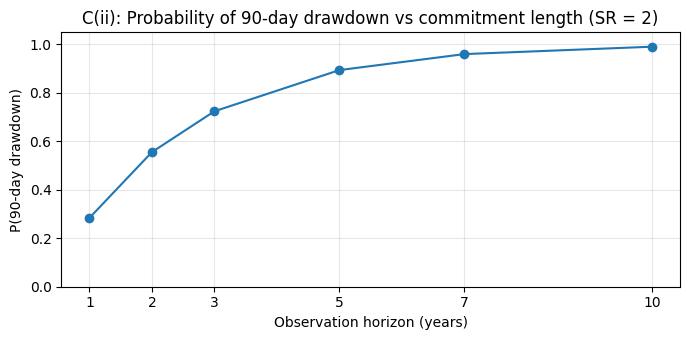

In [61]:
# --- 10-year: P(90-day dd) and P(120-day dd) ---
max_streak_10y = simulate_max_drawdown_duration(0.08, 0.04, n_years=10, n_sims=100_000, seed=42)

print("C(ii) 10-year horizon (SR = 2)")
for threshold in [90, 120]:
    prob = np.mean(max_streak_10y >= threshold)
    se = np.sqrt(prob * (1 - prob) / len(max_streak_10y))
    print(f"      P({threshold}-day drawdown): {prob:.4f}  ({100*prob:.2f}%)")
    print(f"      95% CI: [{prob - 1.96*se:.4f}, {prob + 1.96*se:.4f}]")
    print()

# --- Multi-horizon comparison for intuition ---
horizons = [1, 2, 3, 5, 7, 10]
print("P(90-day drawdown) vs observation horizon:")
print(f"  {'Horizon':>10s}   {'P(dd >= 90)':>12s}")
horizon_probs = []
for h in horizons:
    ms = simulate_max_drawdown_duration(0.08, 0.04, n_years=h, n_sims=100_000, seed=42)
    p = np.mean(ms >= 90)
    horizon_probs.append(p)
    print(f"  {h:>7d} yr   {p:>11.4f}  ({100*p:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(horizons, horizon_probs, "o-", color="C0", linewidth=1.5, markersize=6)
ax.set_xlabel("Observation horizon (years)")
ax.set_ylabel("P(90-day drawdown)")
ax.set_title("C(ii): Probability of 90-day drawdown vs commitment length (SR = 2)")
ax.set_xticks(horizons)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

**Intuition for varying the observation horizon:**

The probability of observing a 90-day drawdown increases monotonically with the length of time you are committed to the fund. A longer horizon provides more opportunities for a long drawdown to start and play out. Even an exceptional manager (SR = 2) is virtually certain to experience a 90-day drawdown if observed for 10 years.

Conversely, shortening the horizon reduces the probability. In the extreme, if the commitment period is shorter than the drawdown threshold itself (e.g., a 60-day lockup vs. a 90-day drawdown), the probability is exactly zero because there are simply not enough days for the drawdown to occur.

This is analogous to flipping a coin many times: the longer you play, the more likely you are to observe a long run of consecutive tails, even if the coin is slightly biased in your favor.

### C (iii) - Drawdown probability table (1-year lockup, varying Sharpe Ratio)

BCM is a typical start-up hedge fund with a 1-year lockup. We vary the Sharpe Ratio from $-1$ to $3$ (incrementing by $0.5$) while holding $\sigma = 4\%$ fixed ($\mu = \text{SR} \times \sigma$). For each SR we estimate the probability of observing a drawdown of a given length **or longer** over the 1-year period.

Note: using the same random seed for every SR means each Sharpe ratio sees the same underlying noise (only the drift changes), which guarantees strict monotonicity across columns.

Drawdown (days),SR=-1.0,SR=-0.5,SR=+0.0,SR=+0.5,SR=+1.0,SR=+1.5,SR=+2.0,SR=+2.5,SR=+3.0
1,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
3,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
5,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
10,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
20,1.000,1.000,1.000,1.000,0.999,0.998,0.994,0.986,0.968
40,0.999,0.996,0.990,0.976,0.948,0.898,0.822,0.721,0.603
60,0.991,0.975,0.945,0.888,0.803,0.690,0.559,0.423,0.300
90,0.952,0.901,0.819,0.703,0.564,0.418,0.284,0.177,0.100
120,0.885,0.794,0.669,0.524,0.375,0.243,0.142,0.074,0.036


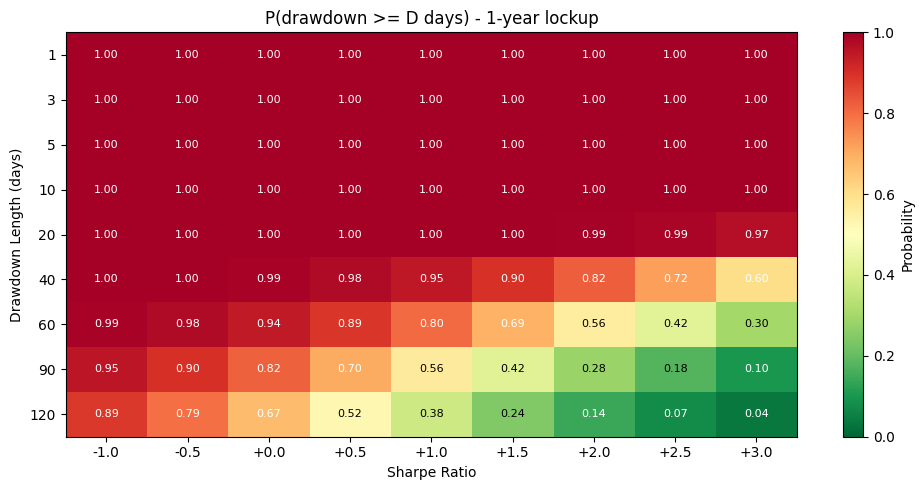

In [62]:
sharpe_ratios = np.arange(-1.0, 3.5, 0.5)   # -1, -0.5, 0, ..., 3
dd_lengths    = [1, 3, 5, 10, 20, 40, 60, 90, 120]
sigma_fixed   = 0.04
n_sims        = 100_000

# Run simulation once per SR; reuse max_streak for all dd thresholds
results = {}
for sr in sharpe_ratios:
    mu = sr * sigma_fixed
    max_streak = simulate_max_drawdown_duration(mu, sigma_fixed,
                                                 n_years=1, n_sims=n_sims, seed=42)
    for ddl in dd_lengths:
        results[(sr, ddl)] = np.mean(max_streak >= ddl)

# Build DataFrame
table_data = []
for ddl in dd_lengths:
    row = {"Drawdown (days)": ddl}
    for sr in sharpe_ratios:
        row[f"SR={sr:+.1f}"] = results[(sr, ddl)]
    table_data.append(row)

df_ciii = pd.DataFrame(table_data)

sr_cols = [c for c in df_ciii.columns if c != "Drawdown (days)"]
display(
    df_ciii.style
    .format({col: "{:.3f}" for col in sr_cols})
    .hide(axis="index")
    .set_caption("P(drawdown >= D days) over a 1-year lockup")
)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
heat_data = df_ciii[sr_cols].values.astype(float)
im = ax.imshow(heat_data, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1)
ax.set_xticks(range(len(sr_cols)))
ax.set_xticklabels([f"{sr:+.1f}" for sr in sharpe_ratios])
ax.set_yticks(range(len(dd_lengths)))
ax.set_yticklabels(dd_lengths)
ax.set_xlabel("Sharpe Ratio")
ax.set_ylabel("Drawdown Length (days)")
ax.set_title("P(drawdown >= D days) - 1-year lockup")

for i in range(len(dd_lengths)):
    for j in range(len(sharpe_ratios)):
        val = heat_data[i, j]
        color = "white" if val > 0.6 or val < 0.15 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

fig.colorbar(im, ax=ax, label="Probability")
fig.tight_layout()
plt.show()

## Part D - Discussion

### What do drawdown probabilities teach us about measuring a manager's skill?

The C(iii) table reveals that drawdowns are a **noisy signal** of manager skill, especially over short observation windows. Consider the 90-day drawdown row: an unskilled manager (SR = 0) has an 81.9% probability of experiencing one within a year, while a highly skilled manager (SR = 2) still has a 28.4% probability. That means roughly 1-in-4 excellent managers will suffer a 90-day drawdown in their first year purely due to random variation. For shorter drawdowns the signal is even worse - every Sharpe Ratio from -1 to +3 shows a 100% probability of experiencing drawdowns up to 10 days, making short drawdowns completely uninformative about skill.

Even at the extreme end of the table, the separation between skill levels is modest. An SR = 3 manager (extraordinary by any standard) still has a 10% chance of a 90-day drawdown and a 3.6% chance of a 120-day drawdown in a single year. Meanwhile, an SR = 0.5 manager has a 70.3% chance of a 90-day drawdown. A Bayesian investor who observes a 90-day drawdown would update meaningfully (the likelihood ratio between SR = 0 and SR = 2 is about 2.9:1), but this is far from sufficient for confident inference about the true Sharpe Ratio from a single year of observation. Multiple years of data are needed before drawdown frequency becomes a reliable discriminator of skill.

**Lesson:** Drawdowns are inevitable, even for truly skilled managers. A single drawdown observation does carry information (it shifts the posterior toward lower skill), but not nearly enough for confident conclusions. Investors and managers who treat individual drawdowns as definitive signals will systematically make poor allocation decisions.

---

### Implications for setting up a hedge fund (as a manager)

If you are managing a hedge fund, these results should directly shape your fund structure:

- **Negotiate the longest possible lockup period.** The multi-horizon analysis in C(ii) shows that even with SR = 2, there is a 28.4% chance of a 90-day drawdown in year 1, 55.6% over 2 years, and 89.4% over 5 years. With a 1-year lockup, more than a quarter of your paths will show a 90-day drawdown. Investors with a short lockup may redeem during this drawdown, which could force you to liquidate positions at the worst possible time. A 3-to-5 year lockup gives your strategy the statistical runway it needs.

- **Set investor expectations upfront.** Include the C(iii) drawdown probability table (or something like it) in your offering documents and pitch materials. Educate investors that a 90-day drawdown is not evidence of broken strategy but a statistically expected event. This pre-commitment reduces the likelihood of panic redemptions.

- **Maintain cash reserves or credit facilities.** Since drawdowns are inevitable, ensure you have sufficient liquidity to meet margin calls and operational costs during drawdown periods without selling positions at distressed prices.

- **Choose your investor base carefully.** Seek institutional investors who understand quantitative strategies and have long-term mandates, rather than retail or high-net-worth investors who may be more reactive to short-term losses.

---

### How long before you can evaluate a manager's skill?

The standard error of the realized Sharpe Ratio estimated over $T$ years is approximately $\sqrt{(1 + SR^2/2) \,/\, T}$ (Lo, 2002). This accounts for the fact that estimating the Sharpe Ratio requires estimating both the mean and the variance, and the estimation error grows with the true SR itself. To distinguish an SR = 2 manager from an SR = 0 manager with 95% confidence, we need the difference (2.0) to exceed $1.96 \times SE$:

$$T \geq \frac{1.96^2 \,(1 + SR^2/2)}{SR^2}$$

For SR = 2: $T \geq 3.84 \times 3/4 \approx 3$ years. For a more realistic SR = 1 manager vs. SR = 0: $T \geq 3.84 \times 1.5 \approx 6$ years. For a modest-skill manager with SR = 0.5: $T \geq 3.84 \times 4.5 \approx 17$ years.

In practice, most hedge fund investors evaluate managers on 1-to-3 year track records. The analysis above shows this is grossly insufficient. Even distinguishing a truly exceptional SR = 2 manager from zero skill requires roughly 3 years of data. For more realistic skill levels (SR around 1), you need at least 6 years before drawing any statistically meaningful conclusions. This reinforces the lesson from Part C: short observation windows cannot reliably separate skill from luck.

---

### Do winning rates and up-down ratios help learn about skill?

Under the normality and i.i.d. assumptions of this problem, the answer is **no, they provide no additional information beyond what the Sharpe Ratio already tells you.** As demonstrated in Part B, both the winning rate and the up-down ratio are deterministic functions of the Sharpe Ratio. Observing a 55% winning rate with a 1.12 up-down ratio tells you the same thing as observing SR = 2 directly - these are just different ways of expressing the same underlying parameter.

In practice, however, departures from this relationship could be informative. If a manager exhibits a winning rate that is significantly higher than what their Sharpe Ratio would predict under normality, it might signal that their return distribution is skewed (e.g., consistent small gains punctuated by rare large losses, as in a short-volatility strategy). This is useful information for **risk management** (understanding the tail risk profile) but does not directly tell you whether the manager has alpha. The winning rate and up-down ratio are descriptors of the return distribution's shape, not of its center.

---

### Connection to the Limits of Arbitrage

The Limits of Arbitrage framework (Shleifer and Vishny, 1997) argues that even when arbitrageurs identify genuine mispricings, they may be unable to fully exploit them because they manage other people's money. The central mechanism is **performance-based arbitrage**: investors allocate capital based on recent returns, withdrawing after losses and adding after gains. This creates a perverse dynamic where capital is least available precisely when opportunities are greatest (during market dislocations).

Our drawdown analysis quantifies this constraint directly. The C(iii) table shows that a truly skilled manager (SR = 2) has a 28.4% chance of a 90-day drawdown within the first year. If investors have a 1-year lockup and use drawdowns as a signal to redeem, then roughly 1-in-4 skilled managers will face redemption pressure in their first year - not because their strategy is broken, but because of normal statistical variation. This forced liquidation during drawdowns is exactly the mechanism that Shleifer and Vishny describe: it prevents arbitrageurs from maintaining positions through temporary mispricings, allowing the mispricings to persist or even widen.

The C(ii) results reinforce this: over longer horizons, drawdowns become virtually certain (99.1% over 10 years). This means that even with permanent capital, a manager will face periods where their cumulative track record looks poor. The limits of arbitrage are not just about access to capital - they are also about the psychological and institutional tolerance for inevitable periods of underperformance.

---

### Connection to the Fundamental Law of Active Management

The Fundamental Law of Active Management (Grinold and Kahn) states that $IR = IC \times \sqrt{BR}$, where the Information Ratio depends on the manager's skill per bet (Information Coefficient, $IC$) and the number of independent bets ($BR$, breadth).

This framework helps explain the frequency paradox we observe in this problem. Under the i.i.d. assumption of this problem, each daily return is an independent draw, so a daily strategy effectively makes 252 independent bets per year ($BR = 252$), compared to a monthly strategy with $BR = 12$. (In practice, breadth depends on the actual number of independent decisions the strategy takes, which may be much less than the number of trading days - for example, a trend-following strategy holding positions for weeks has far fewer independent bets than trading days.) For the same $IC$, a strategy with higher breadth achieves a higher $IR$ (by a factor of $\sqrt{252/12} \approx 4.6$). This means higher-breadth strategies accumulate statistical evidence of skill much faster than lower-breadth strategies.

However, more frequent observation also means more frequent observation of losses. Part A showed that even with SR = 2, the probability of losing money on any given day is 44.99%. An investor observing daily returns will see losses on nearly half of all days. The same strategy observed monthly shows losses only 28.19% of the time, and annually only 2.28% of the time. The underlying skill is identical - what changes is the signal-to-noise ratio at the observation frequency.

This connects directly to the breadth dimension of the Fundamental Law: higher breadth improves the expected risk-adjusted return, but it also generates more granular data that can be misinterpreted. A high-breadth strategy needs its investors to understand that frequent losses at the individual-bet level are statistically expected and do not indicate broken strategy.

---

### Reporting frequency - pros and cons of greater transparency

The results above suggest a nuanced view of reporting frequency:

**Pros of higher-frequency reporting:**
- **Risk oversight.** More frequent reporting allows investors and risk managers to detect genuine problems faster - for example, a breach of risk limits, unexpected concentration in a single position, or a fundamental change in the strategy's factor exposures (style drift).
- **More data for evaluation.** Daily returns provide 252 data points per year vs. 12 for monthly and 4 for quarterly. This accelerates the statistical evaluation of manager skill (connecting to the Fundamental Law's breadth dimension).
- **Alignment and trust.** Transparency builds trust between managers and investors and reduces agency problems.

**Cons of higher-frequency reporting:**
- **Noise-driven anxiety.** Part A showed that a manager with SR = 2 loses money on 44.99% of days. Showing daily PnL to investors who are not statistically sophisticated can create unnecessary anxiety and pressure to deviate from the strategy.
- **Premature redemption.** The C(iii) table shows that short drawdowns are uninformative (100% probability for all Sharpe Ratios up to 10 days). If investors react to short drawdowns by redeeming, they are acting on pure noise, harming both themselves and the manager. This is the Limits of Arbitrage problem applied to fund management.
- **Myopic loss aversion.** Behavioral finance research (Benartzi and Thaler, 1995) shows that the more frequently investors evaluate their portfolios, the more loss-averse they become, because they observe more frequent (but smaller) losses. This leads investors to demand excessively high risk premiums or to flee strategies that are performing within normal statistical bounds.

**Optimal approach:** Report risk metrics (exposure, concentration, factor loadings) and portfolio positions at high frequency for oversight and governance purposes. But frame performance evaluation on longer horizons (quarterly or annually) where the signal-to-noise ratio is higher. This gives investors the transparency they need for risk management without creating the noise-driven behavioral problems that undermine the manager's ability to execute the strategy.